In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Explore Shapley Values

What happens when there are multiple copies of the same feature?

Observations:
- Even when a bunch of variables are highly correlated (e.g., z1, z2, z3, ... etc.), they are assigned unequal weights in SHAP
- Depending on random runs of the data, different variables get selected
- When y is dependent on both X and Z, essentially any ordering appears to be possible (although Z's tend to be on top)
- When y is dependent on ONLY X, we sometimes get the (expected) outcomes that the X's come out on top, but sometimes get the outcome that Z's come out on top (!!)

In [57]:
x = np.random.rand(100)

In [58]:
z = np.random.rand(100)

In [59]:
# Create some copies of X
x1 = pd.DataFrame({"x1": 3*x})
x2 = pd.DataFrame({"x2": 4*x})
x3 = pd.DataFrame({"x3": 5*x})

In [60]:
# Create some copies of Z
z1 = pd.DataFrame({"z1": 3*z})
z2 = pd.DataFrame({"z2": 4*z})
z3 = pd.DataFrame({"z3": 5*z})
z4 = pd.DataFrame({"z4": 6*z})
z5 = pd.DataFrame({"z5": 7*z})
z6 = pd.DataFrame({"z6": 8*z})
z7 = pd.DataFrame({"z7": 9*z})
z8 = pd.DataFrame({"z8": 10*z})
z9 = pd.DataFrame({"z9": 11*z})
z10 = pd.DataFrame({"z10": 12*z})
z11 = pd.DataFrame({"z11": 13*z})
z12 = pd.DataFrame({"z12": 14*z})

In [61]:
# Create Y, which is a function of X and Z + some random number
# y = pd.DataFrame({"y": x * z + np.random.rand(100)*np.random.rand(100)})

# Case where y is only a function of x
y = pd.DataFrame({"y": x + np.random.rand(100)*np.random.rand(100)})

In [62]:
# Train a lasso model

X = pd.concat([x1, x2, x3, z1, z2, z3, z4, z5, z6, z7, z8, z9, z10, z11, z12], axis = 1)

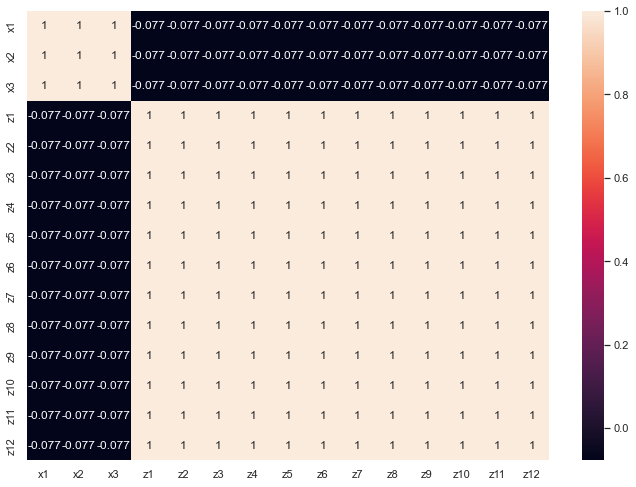

In [63]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
ax = sns.heatmap(X.corr(), annot=True)

In [64]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [65]:
# Look at the relevant SHAP
explainer = shap.LinearExplainer(model, X)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


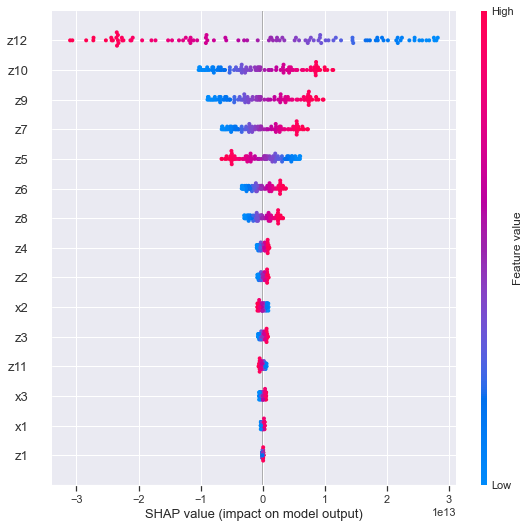

In [66]:
shap.summary_plot(explainer.shap_values(X), X)